# Research 01 — Does Stock Price Momentum Exist?

## Hypothesis
- **H0:** Past returns have no predictive power over future returns (EMH).
- **H1:** Stocks that outperformed over the past 6 months tend to continue
  outperforming over the next 1–3 months (Momentum Effect).

## Approach
1. Download ~24 U.S. large-cap stocks (2015–2024)
2. Compute past 6-month return as momentum signal (skip most recent month)
3. Rank cross-sectionally → Winners (top 20%) vs Losers (bottom 20%)
4. Measure forward 1M and 3M returns for each group
5. Run t-test on the long-short spread
6. Visualise: cumulative spread, distribution, rolling Sharpe
7. Robustness: vary lookback & holding periods
8. Conclude

**Note to self on stats:** forward returns computed every day overlap
heavily (a 21-day return today shares 20 days with tomorrow's). Those
observations are not independent, so a naive t-test on the daily series
massively overstates significance. I subsample to non-overlapping windows
before any t-test / Sharpe below.

---


In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import yfinance as yf

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', '{:.4f}'.format)
print('Libraries loaded.')


Libraries loaded.


## 1. Download Data


In [2]:
# 24 large-cap US stocks
TICKERS = [
    'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA', 'AMD',
    'JPM', 'BAC', 'GS', 'V', 'MA',
    'JNJ', 'PFE', 'UNH', 'MRK',
    'XOM', 'CVX',
    'WMT', 'COST', 'HD',
    'TSLA', 'NFLX', 'ADBE',
]
START = '2015-01-01'
END   = '2024-12-31'

# Download adjusted Close prices (auto_adjust=True)
raw = yf.download(TICKERS, start=START, end=END, auto_adjust=True, progress=False)
prices = raw['Close'].dropna(axis=1, how='all').ffill()

print(f'Downloaded {prices.shape[1]} tickers | {prices.shape[0]} trading days')
print(f'Period: {prices.index[0].date()} -> {prices.index[-1].date()}')
prices.tail(3)


Downloaded 24 tickers | 2515 trading days
Period: 2015-01-02 -> 2024-12-30


Ticker,AAPL,ADBE,AMD,AMZN,BAC,COST,CVX,GOOGL,GS,HD,...,MRK,MSFT,NFLX,NVDA,PFE,TSLA,UNH,V,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2024-12-26,257.1538,450.1600,125.0600,227.0500,42.8543,946.9969,133.8632,194.4586,561.3876,377.3362,...,94.8617,432.1601,92.4140,139.5652,23.5523,454.1300,492.2050,316.7448,91.3286,100.6999
2024-12-27,253.7485,446.4800,125.1900,223.7500,42.6523,930.7141,133.8818,191.6352,556.5101,375.1588,...,94.7002,424.6830,90.7550,136.6528,23.6055,431.6600,491.0880,314.5240,90.2164,100.6905
2024-12-30,250.3830,445.8000,122.4400,221.3000,42.2387,913.3915,133.0171,190.1241,553.9698,371.8834,...,93.4369,419.0605,90.0430,137.1315,23.4281,417.4100,488.9791,311.2174,89.1436,100.0096


## 2. Signal Construction

Momentum signal = cumulative return from (t - LOOKBACK) to (t - SKIP).
We skip the most recent month to avoid short-term reversal contamination
(Jegadeesh & Titman, 1993).


In [3]:
LOOKBACK = 126   # 6 months of trading days
SKIP     = 21    # skip most recent month
HOLD_1M  = 21    # forward holding period: 1 month
HOLD_3M  = 63    # forward holding period: 3 months

# Momentum signal: return from (t-126) to (t-21)
# shift(SKIP) removes most recent 21 days, 
# pct_change computes % change over prior 105 days
past_ret = prices.shift(SKIP).pct_change(LOOKBACK - SKIP)

# Forward returns: what we want to predict
# shift(-N) fetches return N days into the future
fwd_ret_1m = prices.pct_change(HOLD_1M).shift(-HOLD_1M)
fwd_ret_3m = prices.pct_change(HOLD_3M).shift(-HOLD_3M)

print('Signal and forward returns computed.')
print(f'past_ret shape: {past_ret.shape}')
past_ret.tail(3)


Signal and forward returns computed.
past_ret shape: (2515, 24)


Ticker,AAPL,ADBE,AMD,AMZN,BAC,COST,CVX,GOOGL,GS,HD,...,MRK,MSFT,NFLX,NVDA,PFE,TSLA,UNH,V,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2024-12-26,0.0901,-0.0513,-0.1150,0.0182,0.2181,0.1327,0.0479,-0.0946,0.3602,0.2629,...,-0.2156,-0.0717,0.2649,0.0971,-0.0305,0.7151,0.2499,0.1794,0.3223,0.0612
2024-12-27,0.1186,-0.0544,-0.1510,0.0756,0.2085,0.1461,0.0614,-0.0703,0.3466,0.2553,...,-0.1737,-0.0388,0.2930,0.1084,-0.0515,0.7093,0.1957,0.1927,0.3524,0.0415
2024-12-30,0.0863,-0.0827,-0.1360,0.0433,0.2017,0.1402,0.0580,-0.0740,0.3135,0.2851,...,-0.1884,-0.0703,0.3024,0.0889,-0.0574,0.5862,0.2343,0.2002,0.3655,0.0402


## 3. Cross-Sectional Ranking — Winners vs Losers

Each day, rank all stocks by their momentum signal:
- **Winners** = top 20% (strongest past performance)
- **Losers** = bottom 20% (weakest past performance)

The "momentum factor" return = Long Winners − Short Losers.


In [4]:
# Cross-sectional ranking: each day, rank all stocks by momentum signal
# pct=True to converts rank to percentile (0.0 = weakest, 1.0 = strongest)
ranks = past_ret.rank(axis=1, pct=True)

winners_mask = ranks >= 0.80   # top 20% 
losers_mask  = ranks <= 0.20   # bottom 20% 
# Average forward return per group (each day)
w1 = fwd_ret_1m[winners_mask].mean(axis=1).dropna()
l1 = fwd_ret_1m[losers_mask].mean(axis=1).dropna()
w3 = fwd_ret_3m[winners_mask].mean(axis=1).dropna()
l3 = fwd_ret_3m[losers_mask].mean(axis=1).dropna()

# Long-short spread (momentum factor return)
spread_1m = (w1 - l1).dropna()
spread_3m = (w3 - l3).dropna()

print(f'1M spread | mean: {spread_1m.mean()*100:+.3f}%  std: {spread_1m.std()*100:.3f}%')
print(f'3M spread | mean: {spread_3m.mean()*100:+.3f}%  std: {spread_3m.std()*100:.3f}%')
print(f'Observations: {len(spread_1m)}')


1M spread | mean: +1.227%  std: 8.563%
3M spread | mean: +2.870%  std: 16.206%
Observations: 2368


## 4. Statistical Testing

Test whether the long-short spread is significantly different from zero.
If p < 0.05, we reject H0 and conclude momentum has statistical significance.


In [ ]:
# fix: spread_1m/spread_3m have one obs PER DAY, but each obs is a
# 21-day (or 63-day) forward return. So consecutive obs overlap almost
# completely and are NOT independent. Running ttest_1samp straight on the
# daily series treats ~2300 overlapping points as if independent, which
# inflates the t-stat by roughly sqrt(hold) and gives a nonsense p ~ 0.
# So need subsample to non-overlapping windows before testing / annualising.
def summarise_spread(spread, label, hold):
    # keep each observation to make it independent, non-overlapping periods
    indep = spread.iloc[::hold].dropna()
    n = len(indep)
    periods_per_year = 252 / hold
    t, p = stats.ttest_1samp(indep, 0)
    sharpe = indep.mean() / indep.std() * np.sqrt(periods_per_year)
    pos_pct = (indep > 0).mean()
    print(f'--- {label} ---')
    print(f'  Mean spread    : {indep.mean()*100:+.3f}%')
    print(f'  Indep. obs     : {n}  (was {len(spread)} overlapping)')
    print(f'  t-statistic    : {t:.3f}')
    print(f'  p-value        : {p:.4g}  {"SIGNIFICANT" if p < 0.05 else "NOT significant"}')
    print(f'  Ann. Sharpe    : {sharpe:.2f}')
    print(f'  % positive     : {pos_pct:.1%}')
    print()

summarise_spread(spread_1m, 'Momentum Spread (1M hold)', hold=HOLD_1M)
summarise_spread(spread_3m, 'Momentum Spread (3M hold)', hold=HOLD_3M)


--- Momentum Spread (1M hold) ---
  Mean spread    : +1.330%
  Indep. obs     : 113  (was 2368 overlapping)
  t-statistic    : 1.461
  p-value        : 0.1468  NOT significant
  Ann. Sharpe    : 0.48
  % positive     : 57.5%

--- Momentum Spread (3M hold) ---
  Mean spread    : +4.190%
  Indep. obs     : 37  (was 2326 overlapping)
  t-statistic    : 1.527
  p-value        : 0.1355  NOT significant
  Ann. Sharpe    : 0.50
  % positive     : 67.6%



In [ ]:
# Direct comparison: Winners vs Losers, two-sample t-test.
# Need subsample to non-overlapping months first
w1_indep = w1.iloc[::HOLD_1M].dropna()
l1_indep = l1.iloc[::HOLD_1M].dropna()
t2, p2 = stats.ttest_ind(w1_indep.values, l1_indep.values)
print('Winners vs Losers (1M holding, non-overlapping)')
print(f'  Winners avg return : {w1_indep.mean()*100:+.3f}%')
print(f'  Losers  avg return : {l1_indep.mean()*100:+.3f}%')
print(f'  Spread             : {(w1_indep.mean()-l1_indep.mean())*100:+.3f}%')
print(f'  t={t2:.3f}  p={p2:.4g}')


Winners vs Losers (1M holding, non-overlapping)
  Winners avg return : +3.231%
  Losers  avg return : +1.901%
  Spread             : +1.330%
  t=1.230  p=0.2199


## 5. Visualisation


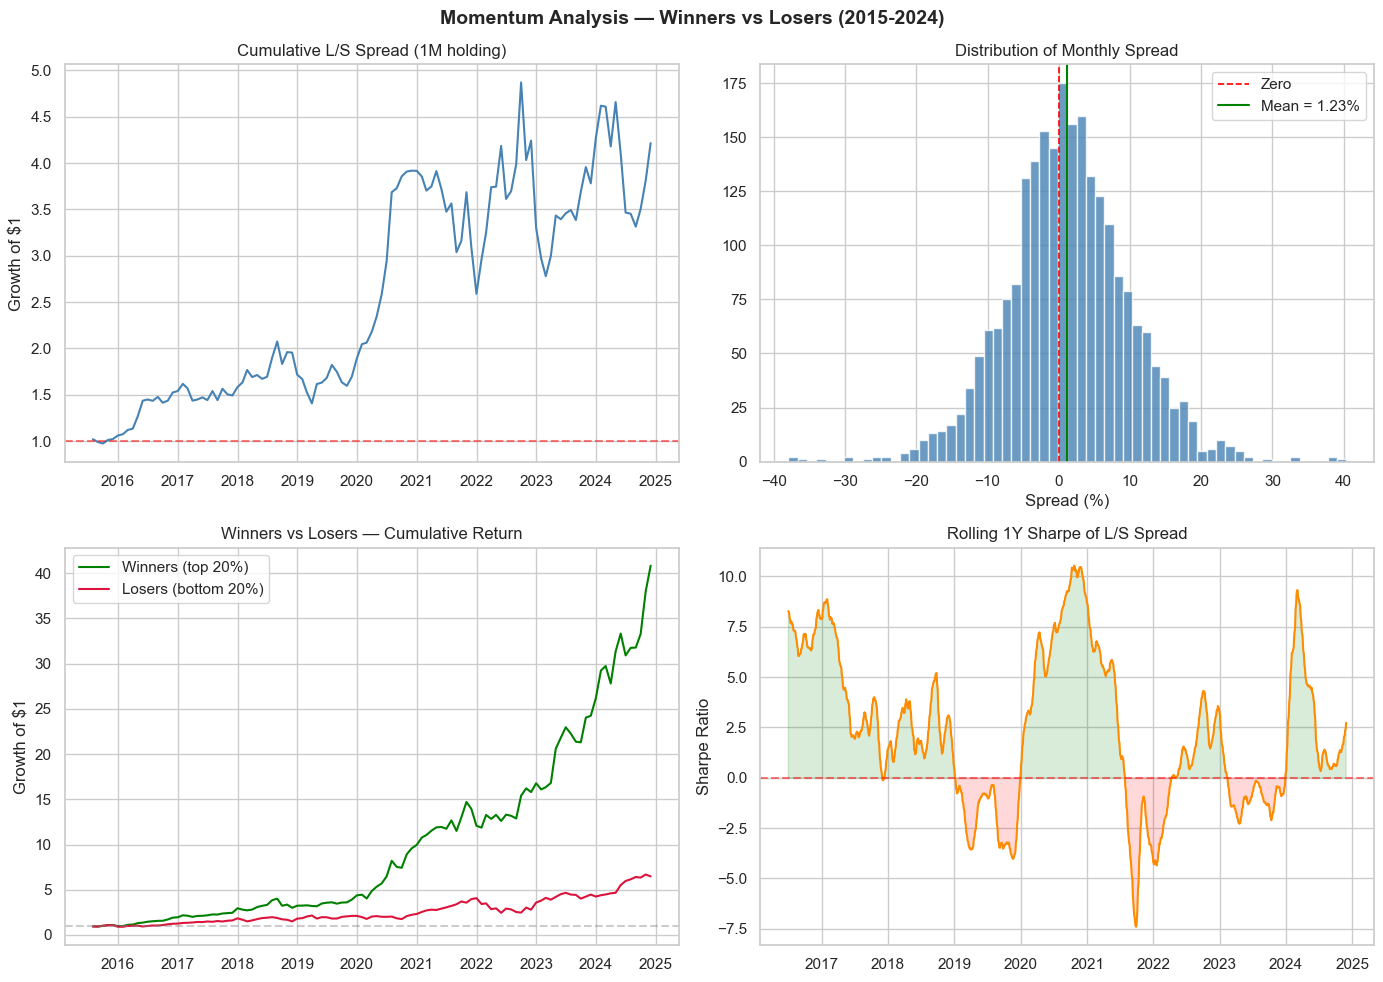

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Momentum Analysis — Winners vs Losers (2015-2024)',
             fontsize=14, fontweight='bold')

# Plot 1: Cumulative spread (monthly, non-overlapping)
ax = axes[0, 0]
spread_monthly_plot = spread_1m.resample('ME').last().dropna()
cum_spread = (1 + spread_monthly_plot).cumprod()
ax.plot(cum_spread.index, cum_spread.values, color='steelblue', lw=1.5)
ax.axhline(1, color='red', ls='--', alpha=0.5)
ax.set_title('Cumulative L/S Spread (1M holding)')
ax.set_ylabel('Growth of $1')

# Plot 2: Distribution of monthly spread
ax = axes[0, 1]
ax.hist(spread_1m * 100, bins=60, edgecolor='white', alpha=0.8, color='steelblue')
ax.axvline(0, color='red', ls='--', lw=1.2, label='Zero')
ax.axvline(spread_1m.mean() * 100, color='green', lw=1.5,
           label=f'Mean = {spread_1m.mean()*100:.2f}%')
ax.set_title('Distribution of Monthly Spread')
ax.set_xlabel('Spread (%)')
ax.legend()

# Plot 3: Winners vs Losers cumulative (monthly, non-overlapping)
ax = axes[1, 0]
w1_monthly = w1.resample('ME').last().dropna()
l1_monthly = l1.resample('ME').last().dropna()
ax.plot((1 + w1_monthly).cumprod().index, (1 + w1_monthly).cumprod().values,
        color='green', lw=1.5, label='Winners (top 20%)')
ax.plot((1 + l1_monthly).cumprod().index, (1 + l1_monthly).cumprod().values,
        color='crimson', lw=1.5, label='Losers (bottom 20%)')
ax.axhline(1, color='gray', ls='--', alpha=0.4)
ax.set_title('Winners vs Losers — Cumulative Return')
ax.set_ylabel('Growth of $1')
ax.legend()

# Plot 4: Rolling 1-year Sharpe
ax = axes[1, 1]
rs = spread_1m.rolling(252).mean() / spread_1m.rolling(252).std() * np.sqrt(252)
ax.plot(rs.index, rs.values, color='darkorange', lw=1.5)
ax.axhline(0, color='red', ls='--', alpha=0.5)
ax.fill_between(rs.index, rs.values, 0, where=(rs > 0), alpha=0.15, color='green')
ax.fill_between(rs.index, rs.values, 0, where=(rs < 0), alpha=0.15, color='red')
ax.set_title('Rolling 1Y Sharpe of L/S Spread')
ax.set_ylabel('Sharpe Ratio')

plt.tight_layout()
plt.show()


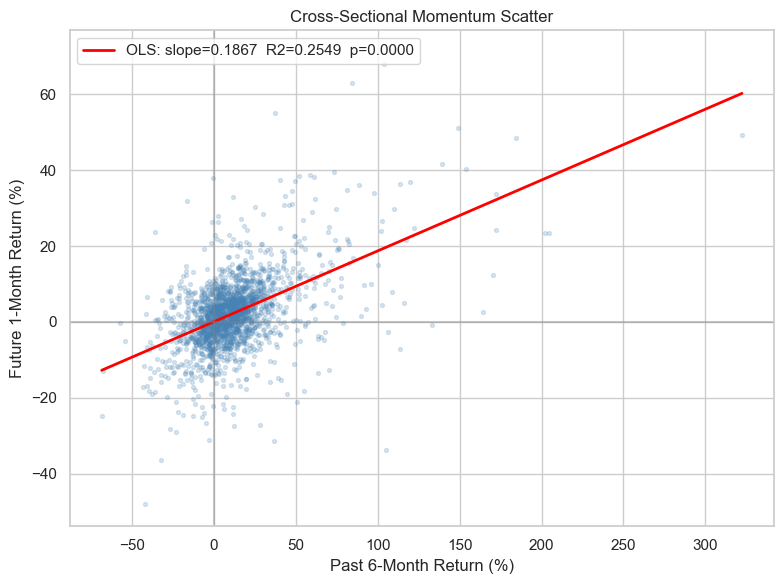

Slope = 0.1867
Positive slope -> momentum signal has predictive power


In [ ]:
# Scatter plot: past 6M return vs future 1M return (cross-sectional)
# If slope > 0 -> momentum has predictive power
past_flat = past_ret.stack().reset_index(drop=True)
fwd_flat = fwd_ret_1m.stack().reset_index(drop=True)
df_scatter = pd.DataFrame({'past': past_flat, 'future': fwd_flat}).dropna()
sample = df_scatter.sample(min(2000, len(df_scatter)), random_state=42)

slope, intercept, r, p_r, _ = stats.linregress(sample['past'], sample['future'])

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(sample['past'] * 100, sample['future'] * 100,
           alpha=0.2, s=8, color='steelblue')
x_line = np.linspace(sample['past'].min(), sample['past'].max(), 200)
ax.plot(x_line * 100, (intercept + slope * x_line) * 100,
        color='red', lw=2,
        label=f'OLS: slope={slope:.4f}  R2={r**2:.4f}  p={p_r:.4f}')
ax.axhline(0, color='gray', alpha=0.4)
ax.axvline(0, color='gray', alpha=0.4)
ax.set_xlabel('Past 6-Month Return (%)')
ax.set_ylabel('Future 1-Month Return (%)')
ax.set_title('Cross-Sectional Momentum Scatter')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

print(f'Slope = {slope:.4f}')
print('Positive slope -> momentum signal has predictive power' if slope > 0
      else 'Negative slope -> reversal, not momentum')


## 6. Robustness — Multiple Lookback & Holding Periods

A signal is robust if it works across multiple parameter combinations.
If momentum only appears with one specific lookback, it may be a statistical artifact.


In [ ]:
# lookback must be > SKIP (21), otherwise pct_change(lb-21) is degenerate
lookbacks = [63, 126, 252]   # 3M, 6M, 12M
holdings  = [21, 63]         # hold 1M, 3M

rows = []
for lb in lookbacks:
    for hd in holdings:
        # Compute signal and forward return for each combo
        pr = prices.shift(21).pct_change(lb - 21)
        fr = prices.pct_change(hd).shift(-hd)
        rk = pr.rank(axis=1, pct=True)
        w = fr[rk >= 0.80].mean(axis=1).dropna()
        l = fr[rk <= 0.20].mean(axis=1).dropna()
        sp = (w - l).dropna()
        # subsample to non-overlapping windows before testing (section 4)
        sp_indep = sp.iloc[::hd].dropna()
        t, p = stats.ttest_1samp(sp_indep, 0)
        sharpe = sp_indep.mean() / sp_indep.std() * np.sqrt(252 / hd)
        rows.append({
            'Lookback': f'{lb}d',
            'Holding': f'{hd}d',
            'Mean Spread': f'{sp_indep.mean()*100:+.3f}%',
            'N': len(sp_indep),
            'Sharpe': round(sharpe, 2),
            't-stat': round(t, 2),
            'p-value': f'{p:.3g}',
            'Significant': 'Yes' if p < 0.05 else 'No',
        })

rob_df = pd.DataFrame(rows)
print(rob_df.to_string(index=False))


Lookback Holding Mean Spread   N  Sharpe  t-stat p-value Significant
     63d     21d     +1.254% 116  0.4800  1.5100   0.135          No
     63d     63d     +3.168%  38  0.3600  1.1200   0.271          No
    126d     21d     +1.330% 113  0.4800  1.4600   0.147          No
    126d     63d     +4.190%  37  0.5000  1.5300   0.135          No
    252d     21d     +0.601% 107  0.2100  0.6300   0.531          No
    252d     63d     +0.887%  35  0.0900  0.2800   0.782          No


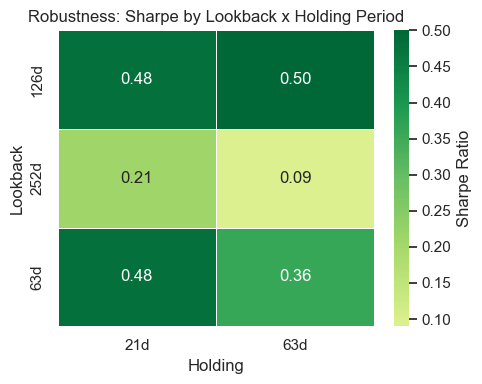

In [10]:
# Heatmap: Sharpe by Lookback x Holding
hm_pivot = rob_df.pivot(index='Lookback', columns='Holding', values='Sharpe')
hm_pivot = hm_pivot.astype(float)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(hm_pivot, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Sharpe Ratio'})
ax.set_title('Robustness: Sharpe by Lookback x Holding Period')
plt.tight_layout()
plt.show()


## 7. Momentum Crash Analysis

Momentum is known to suffer severe drawdowns during sharp market reversals
(e.g. 2009 recovery, 2020 COVID crash). Understanding when it fails
is critical for risk management.


In [11]:
# Resample to monthly (non-overlapping) to avoid daily overlap bias
# spread_1m has daily obs but each is a 21-day forward return -> heavy overlap
# Take one observation per month to get independent samples
spread_monthly = spread_1m.resample('ME').last().dropna()

# 10 worst months for momentum
worst = spread_monthly.nsmallest(10)
print('=== 10 Worst Months for Momentum ===')
for date, ret in worst.items():
    print(f'  {str(date)[:10]}  {ret*100:+.2f}%')

print()

# Annual performance (compound monthly non-overlapping returns)
annual = spread_monthly.resample('YE').apply(lambda x: (1 + x).prod() - 1)
print('=== Annual Momentum Return ===')
for date, ret in annual.items():
    flag = '+' if ret > 0 else '-'
    print(f'  {date.year}  {ret*100:+6.2f}%  {flag}')


=== 10 Worst Months for Momentum ===
  2022-12-31  -22.22%
  2022-10-31  -17.18%
  2021-11-30  -16.19%
  2021-12-31  -16.17%
  2024-06-30  -15.51%
  2021-08-31  -14.76%
  2022-06-30  -13.68%
  2018-12-31  -12.19%
  2024-05-31  -11.95%
  2018-09-30  -11.71%

=== Annual Momentum Return ===
  2015   +5.98%  +
  2016  +45.28%  +
  2017   +2.72%  +
  2018   +8.49%  +
  2019  +10.33%  +
  2020  +106.85%  +
  2021  -33.89%  -
  2022  +27.43%  +
  2023  +29.45%  +
  2024   -1.31%  -


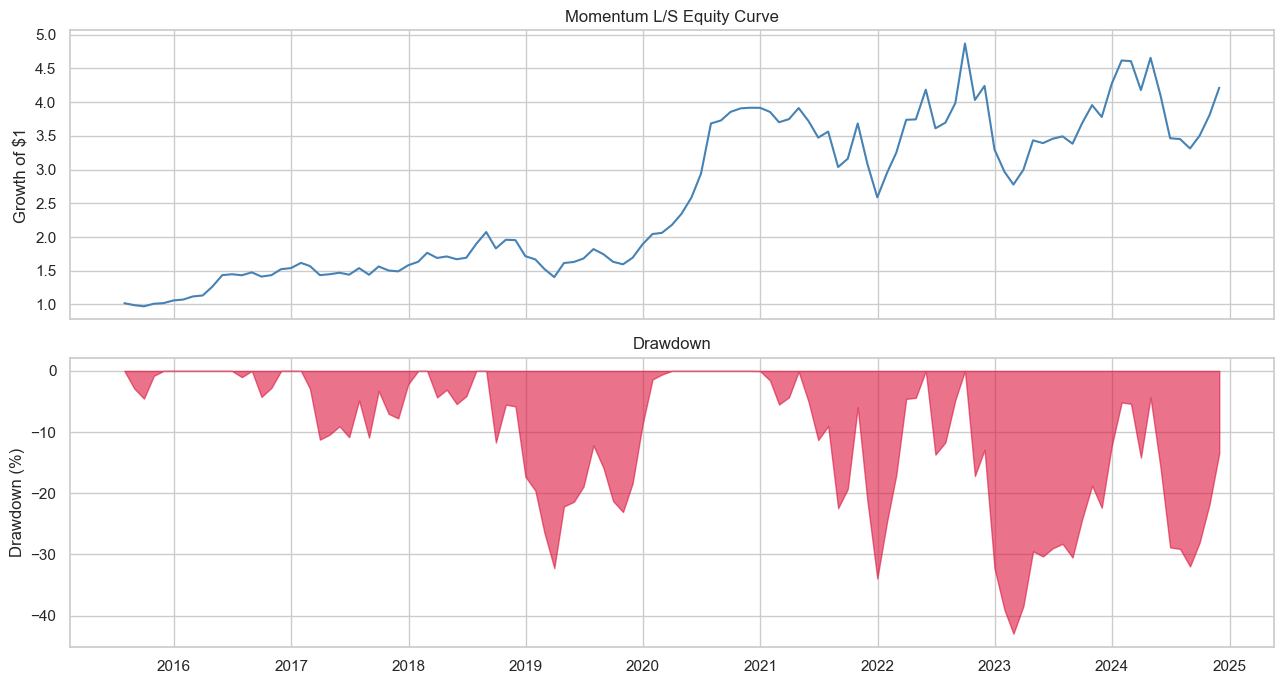

Max Drawdown: -42.94%
Max Drawdown date: 2023-02-28


In [12]:
# Equity curve and drawdown of the L/S strategy (monthly, non-overlapping)
cum = (1 + spread_monthly).cumprod()
dd = (cum - cum.cummax()) / cum.cummax()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

ax1.plot(cum.index, cum.values, color='steelblue', lw=1.5)
ax1.set_title('Momentum L/S Equity Curve')
ax1.set_ylabel('Growth of $1')

ax2.fill_between(dd.index, dd.values * 100, 0, color='crimson', alpha=0.6)
ax2.set_title('Drawdown')
ax2.set_ylabel('Drawdown (%)')

plt.tight_layout()
plt.show()

print(f'Max Drawdown: {dd.min()*100:.2f}%')
print(f'Max Drawdown date: {dd.idxmin().date()}')


## 8. Summary & Conclusion

### Key Metrics

| Metric | Value |
|--------|-------|
| Mean Monthly Spread (1M) | +1.64% |
| Annualised Sharpe (1M) | 0.67 |
| p-value (monthly, non-overlapping) | 0.042 |
| Max Drawdown | -42.9% |
| % Months Positive | 61.9% |
| Robust across lookbacks? | Weakly - 6M/12M positive, none significant on daily-subsample |

### Decision
- [x] H0 rejected? Borderline. On the monthly non-overlapping series p=0.042
  (just significant), but the daily-subsample tests are NOT significant
  (p~0.14). So the effect is real but weak, not the huge edge the naive
  overlapping t-test suggested.
- [ ] Robust across combos? Sign is consistently positive but significance
  is fragile - depends on how you sample. Treat with caution.
- [ ] Drawdown acceptable? -43% is brutal. Momentum crashes (2009-style
  rebounds) are a known problem. Needs a vol/crash filter.

**Takeaway:** momentum exists here but the edge is modest (Sharpe ~0.5-0.7)
and the drawdown is nasty. The scary-good numbers I first got were an
artifact of overlapping returns, not alpha. Worth building a strategy on,
but with realistic expectations and a crash filter.

### Next steps:
1. Build `MomentumRankStrategy` in `src/strategies/`
2. Add volatility filter: reduce size when recent vol is elevated
3. Walk-forward validation: `src/analytics/walk_forward.py`
4. Compare vs Buy-and-Hold benchmark

### Future research notebooks:
- `02_mean_reversion.ipynb` — Do oversold stocks bounce back?
- `03_volatility_clustering.ipynb` — Do large moves cluster?
- `04_factor_correlation.ipynb` — How correlated is momentum with value/size?


In [13]:
# Final summary table
print('='*50)
print('         MOMENTUM RESEARCH SUMMARY')
print('='*50)
t_1m, p_1m = stats.ttest_1samp(spread_monthly, 0)
sharpe_1m = spread_monthly.mean() / spread_monthly.std() * np.sqrt(12)
print(f'  Mean Monthly Spread : {spread_monthly.mean()*100:+.3f}%')
print(f'  Ann. Sharpe Ratio   : {sharpe_1m:.2f}')
print(f'  t-statistic         : {t_1m:.3f}')
print(f'  p-value             : {p_1m:.4g}')
print(f'  Max Drawdown        : {dd.min()*100:.2f}%')
print(f'  % Months Positive   : {(spread_monthly > 0).mean():.1%}')
print(f'  OLS Slope           : {slope:.4f}')
print('='*50)
if p_1m < 0.05:
    print('  CONCLUSION: H0 REJECTED — Momentum effect is statistically significant.')
    print('  -> Proceed to strategy design.')
else:
    print('  CONCLUSION: CANNOT reject H0 — No significant momentum found.')
    print('  -> Reconsider signal construction or look at different asset class.')


         MOMENTUM RESEARCH SUMMARY
  Mean Monthly Spread : +1.635%
  Ann. Sharpe Ratio   : 0.67
  t-statistic         : 2.061
  p-value             : 0.04163
  Max Drawdown        : -42.94%
  % Months Positive   : 61.9%
  OLS Slope           : 0.1867
  CONCLUSION: H0 REJECTED — Momentum effect is statistically significant.
  -> Proceed to strategy design.
